## Performing Linear Regression in Keras

In [ ]:
import tensorflow as tf
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from tensorflow.keras import layers
from keras import Sequential

sns.set_style('white')

from sklearn.datasets import fetch_openml

bike_sharing = fetch_openml("Bike_Sharing_Demand", version=2, as_frame=True)
df = bike_sharing.frame

df.head()

,season,year,month,hour,holiday,weekday,workingday,weather,temp,feel_temp,humidity,windspeed,count
0,spring,0,1,0,False,6,False,clear,9.84,14.395,0.81,0.0,16
1,spring,0,1,1,False,6,False,clear,9.02,13.635,0.80,0.0,40
2,spring,0,1,2,False,6,False,clear,9.02,13.635,0.80,0.0,32
3,spring,0,1,3,False,6,False,clear,9.84,14.395,0.75,0.0,13
4,spring,0,1,4,False,6,False,clear,9.84,14.395,0.75,0.0,1


## Bivariate Analysis

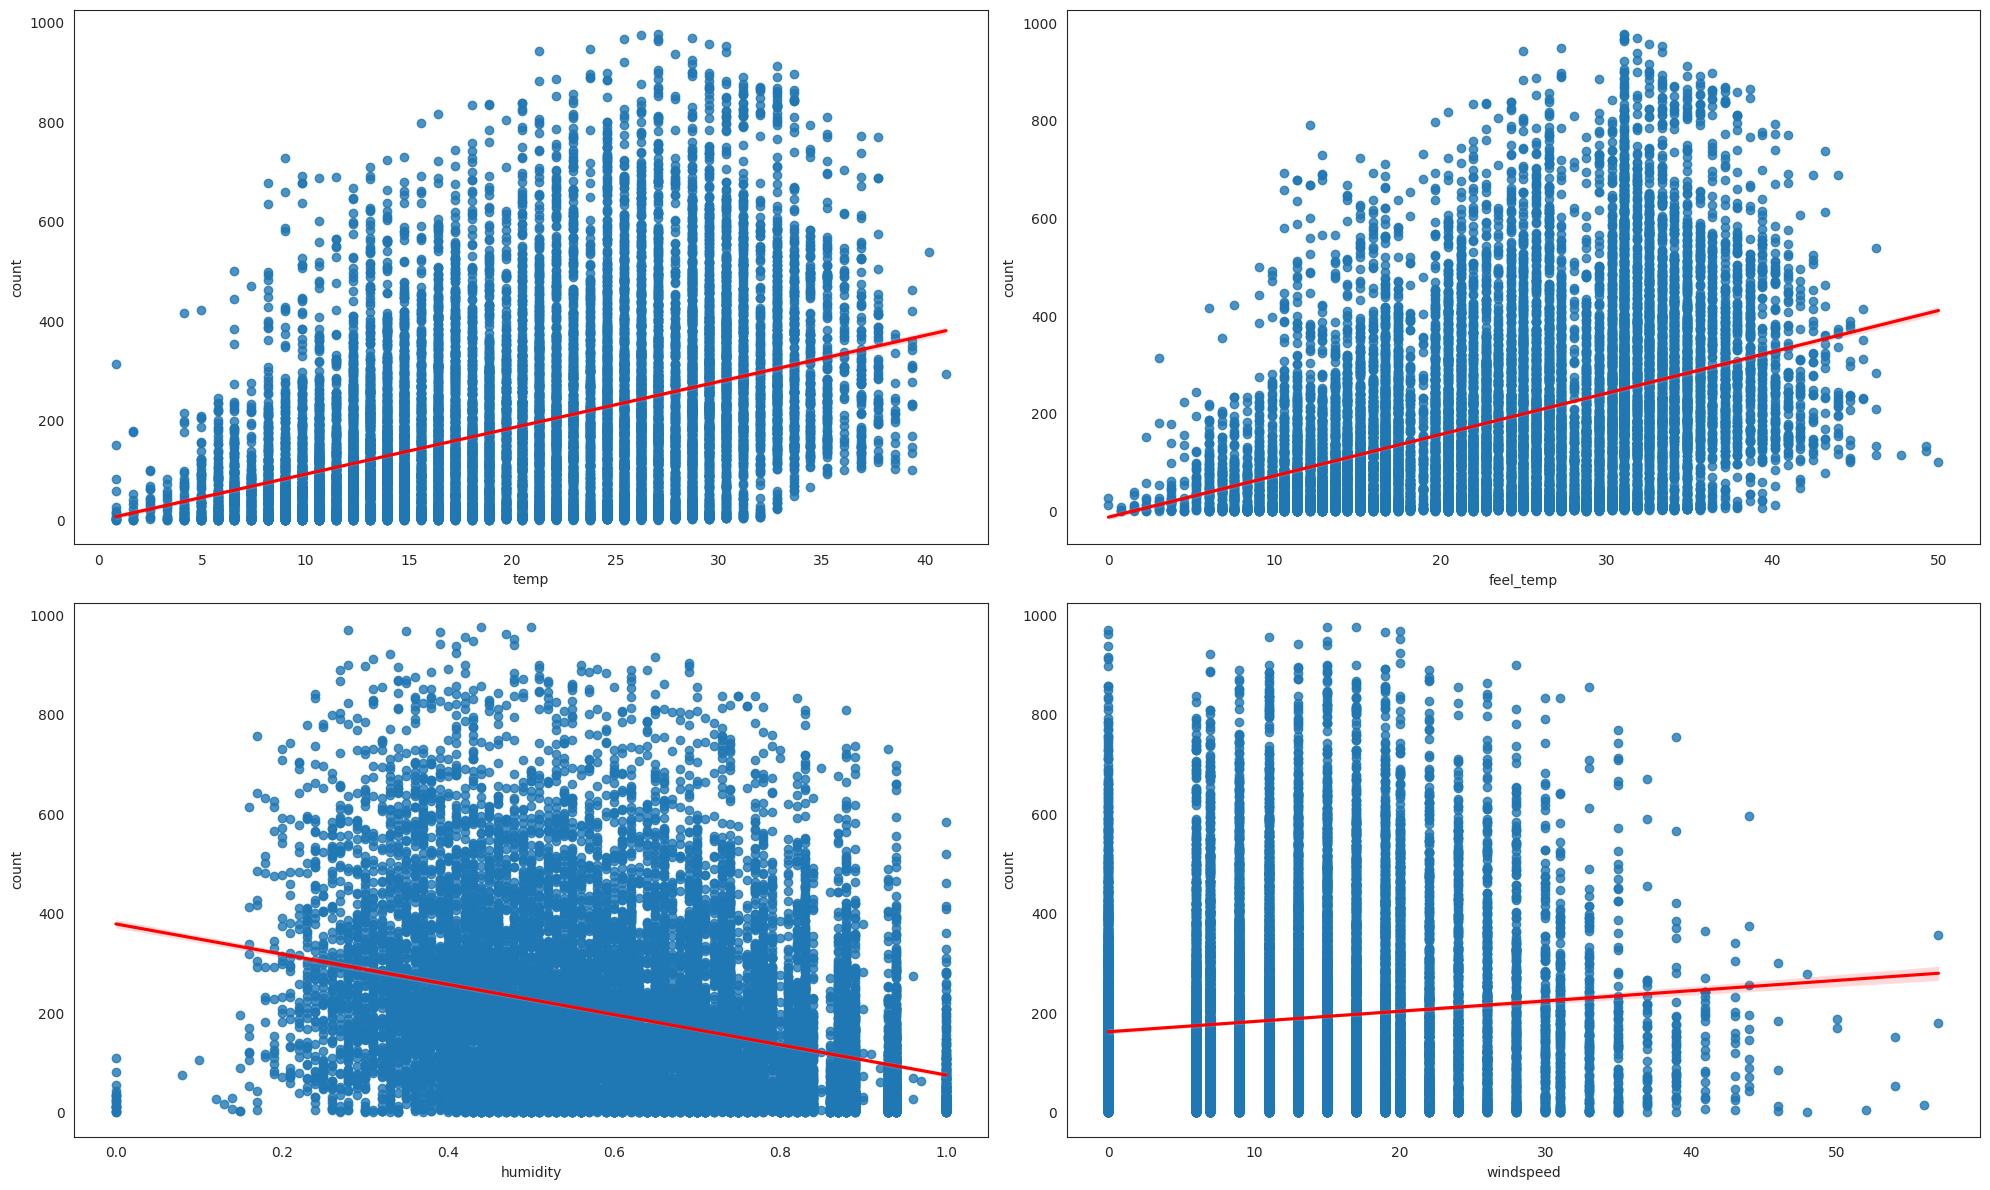

In [11]:
cols = ['temp', 'feel_temp', 'humidity', 'windspeed']

plt.figure(figsize=(20, 12))

for i, col in enumerate(cols):

    plt.subplot(2, 2, i + 1)
    sns.regplot(data=df, x=col, y='count', line_kws={"color":'red'})

plt.tight_layout()

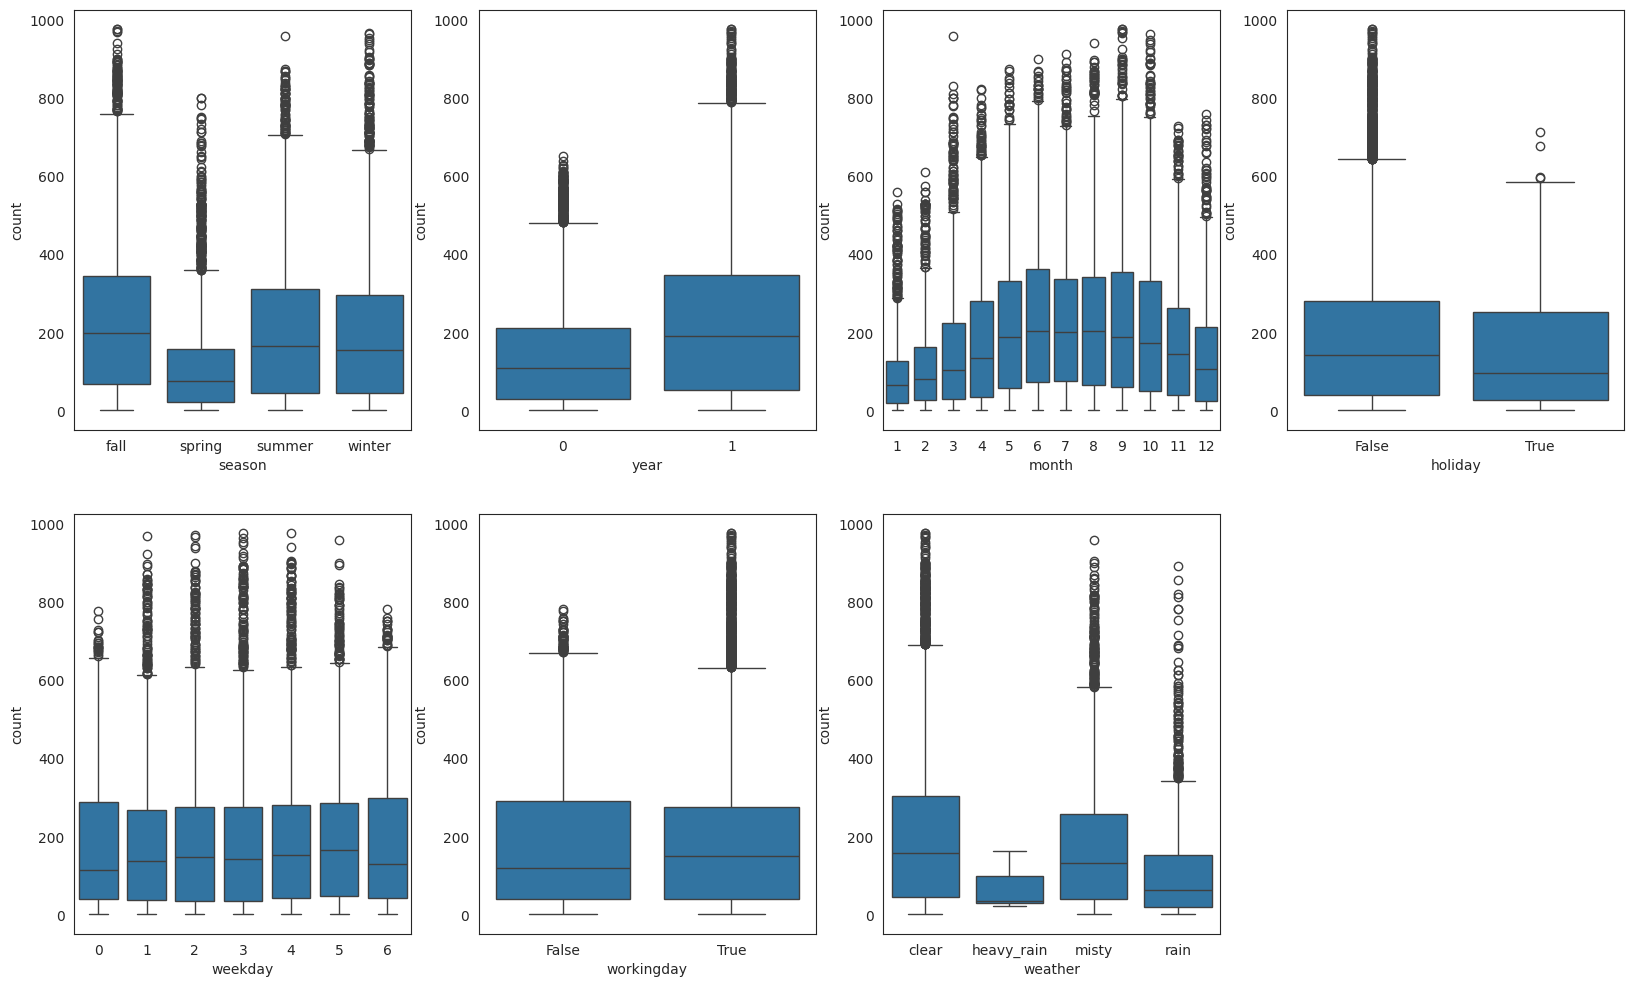

In [12]:
columns = [
    'season', 'year', 'month', 'holiday',
    'weekday', 'workingday', 'weather'
]

plt.figure(figsize=(20, 12))

for i, cols in enumerate(columns):
    plt.subplot(2, 4, i + 1)
    sns.boxplot(data=df, x=cols, y='count')

## Multivariate Analysis

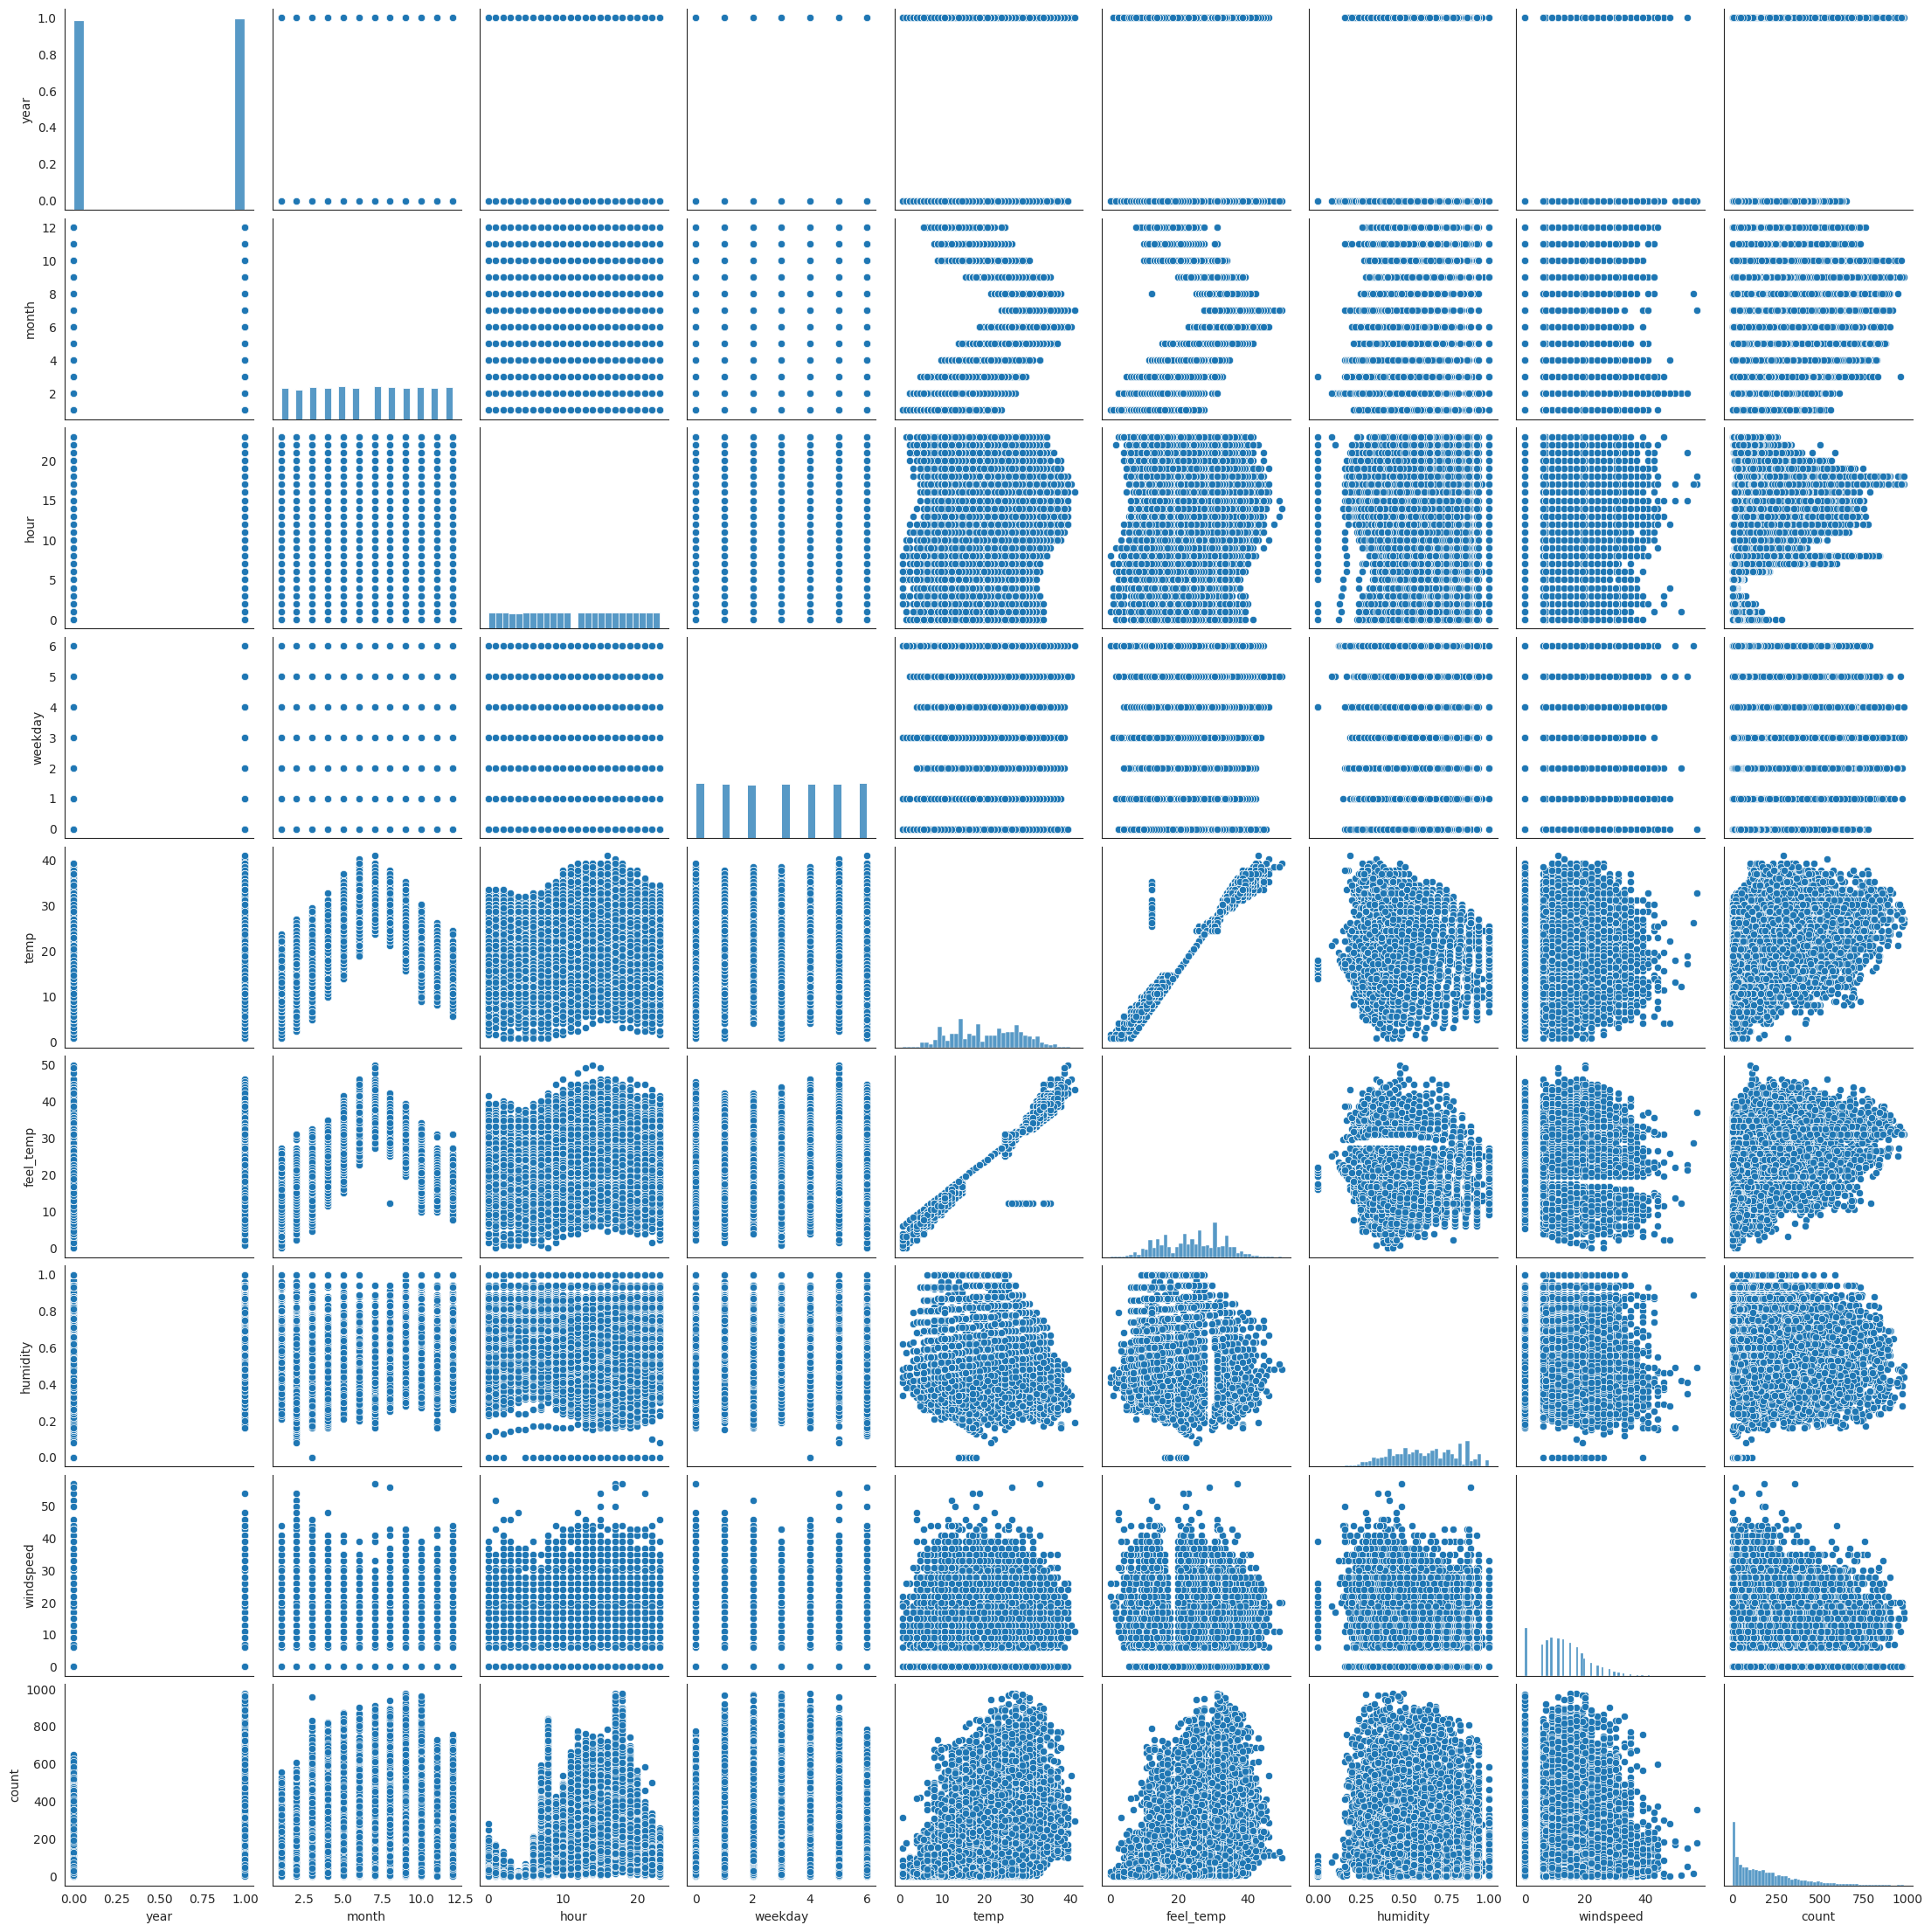

In [13]:
sns.pairplot(df)

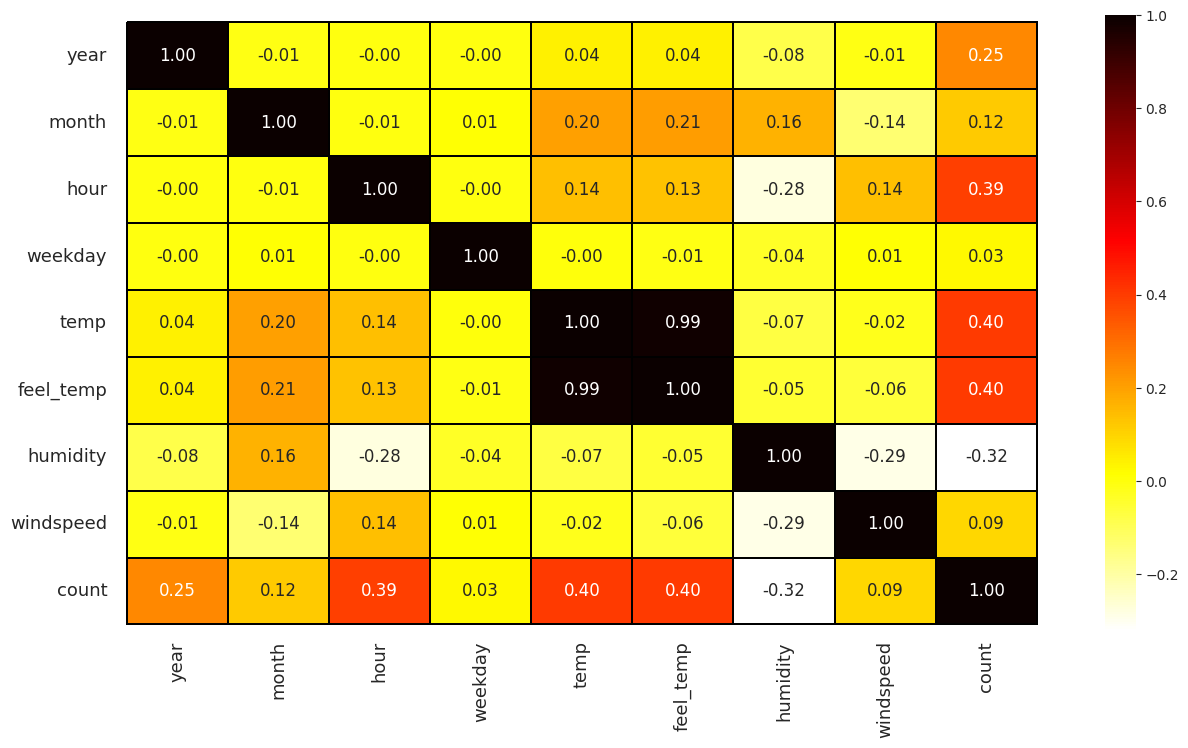

In [15]:
# heatmap columns
plt.figure(figsize=(15,8))
fig = sns.heatmap(df.corr(numeric_only=True),cmap='hot_r',
            annot=True,linecolor='black',linewidths=0.01,annot_kws={"fontsize":12},fmt="0.2f")

top, bottom = fig.get_ylim()
fig.set_ylim(top+0.1,bottom-0.1)

left, right = fig.get_xlim()
fig.set_xlim(left-0.1,right+0.1) 

plt.yticks(fontsize=13,rotation=0)
plt.xticks(fontsize=13,rotation=90);

## Splitting Data into Train/Test Sets

In [17]:
df = pd.get_dummies(df, drop_first=True, dtype=int)

train_dataset = df.sample(frac=0.8, random_state=42)
test_dataset = df.drop(train_dataset.index)

train_features = train_dataset.copy()
test_features = test_dataset.copy()

train_labels = train_features.pop('count')
test_labels = test_features.pop('count')

# normalization using: tf.keras.layers.Normalization

normalizer = tf.keras.layers.Normalization(axis=-1)
normalizer.adapt(np.array(train_features))

In [18]:
print(normalizer.mean.numpy())
print(normalizer.variance.numpy())

[[4.9881321e-01 6.5325470e+00 1.1553909e+01 3.0091348e+00 2.0403332e+01
  2.3817923e+01 6.2647700e-01 1.2734392e+01 2.4347264e-01 2.5469324e-01
  2.4124290e-01 2.9130403e-02 6.8460047e-01 2.1578076e-04 2.6181400e-01
  8.2140543e-02]]
[[2.4999858e-01 1.1792061e+01 4.7693256e+01 4.0096269e+00 6.2272366e+01
  7.3677101e+01 3.7396695e-02 6.7496391e+01 1.8419372e-01 1.8982460e-01
  1.8304476e-01 2.8281823e-02 2.1592267e-01 2.1573421e-04 1.9326743e-01
  7.5393476e-02]]


In [19]:
print(np.array(train_features[:1]))

[[ 1.     6.    19.     6.    32.8   34.85   0.27  12.998  0.     0.
   0.     0.     0.     0.     0.     0.   ]]


In [20]:
print(normalizer(np.array(train_features[:1])).numpy())

[[ 1.0023764  -0.15508261  1.0782012   1.4936364   1.5709316   1.2852601
  -1.8433801   0.0320862  -0.56729996 -0.58457625 -0.56386596 -0.17321791
  -1.4732895  -0.01469106 -0.59554356 -0.29915115]]


## Training a Linear Regression

In [32]:
temp = np.array(train_features['temp'])
temp_norm = layers.Normalization(input_shape=[1,], axis=None)
temp_norm.adapt(np.array(train_features['temp']).astype('float32'))

model = tf.keras.Sequential([
    temp_norm, layers.Dense(units=1)
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_5 (Normalization) │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5 (24.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 3 (16.00 B)

In [33]:
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
    loss='mean_squared_error'
)

history = model.fit(
    train_features['temp'],
    train_labels,
    verbose=True,
    epochs=100,
    validation_split=0.2
)

Epoch 1/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 48685.5273 - val_loss: 41322.9258
Epoch 2/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 32314.4531 - val_loss: 32817.3633
Epoch 3/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 28221.5625 - val_loss: 30488.3184
Epoch 4/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 27206.2656 - val_loss: 29799.6660
Epoch 5/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 26953.1895 - val_loss: 29579.9004
Epoch 6/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 26890.7285 - val_loss: 29489.8379
Epoch 7/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 26874.3887 - val_loss: 29456.7832
Epoch 8/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 26870.3203 - val_loss: 29438.7207
Epoch 9/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 26869.0430 - val_loss: 29439.4355
Epoch 10/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 26868.8770 - val_loss: 29431.1602
Epoch 11/100
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/

In [34]:
def plot_loss(history):
    plt.plot(history.history['loss'], label='loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.legend()
    plt.grid(True)

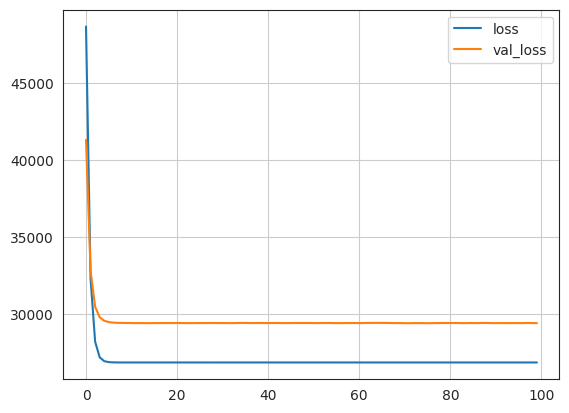

In [35]:
plot_loss(history)

In [36]:
y_pred = model.predict(test_features['temp'])
print(np.sqrt(mean_squared_error(test_labels, y_pred)))

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
167.54387834795696


109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


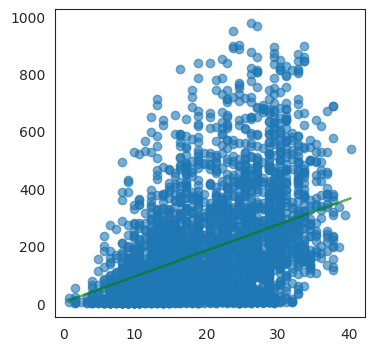

In [39]:
plt.figure(figsize = (4,4))
plt.plot(test_features['temp'], test_labels,'o',
         test_features['temp'],model.predict(test_features['temp']),'g', alpha=0.6)
plt.show()

## Using Neural Networks for Linear Regression

In [43]:
df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module1/L2/data/IowaHousingPrices.csv')

x_train = df[['SquareFeet']].values[1:-500]
y_train = df[['SalePrice']].values[1:-500]
x_test = df[['SquareFeet']].values[-500:]
y_test = df[['SalePrice']].values[-500:]

# define parameters
output_size=1
hidden_layer=500
input_size=1
learning_rate=0.51
loss_function='mean_squared_error'
epochs=30
batch_size=10

Epoch 1/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 5599728128.0000
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3598927616.0000
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4211890944.0000
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3872482560.0000
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3952989696.0000
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3308863744.0000
Epoch 7/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3386545920.0000
Epoch 8/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3354917888.0000
Epoch 9/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3504954368.0000
Epoch 10/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3892502016.0000
Epoch 11/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3413160448.0000
Epoch 12/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3400837888.0000
Epoch 13/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3263336704.0000
Epoch 14/30
96/96 ━━━━━━━━━━━━━━━━

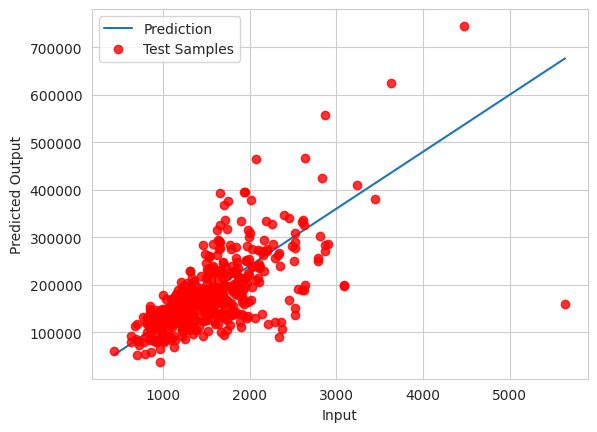

In [46]:
from keras.optimizers import Adam
from keras.models import Sequential
from keras.layers import Dense

model = Sequential()

# add layers
model.add(Dense(hidden_layer, activation='relu'))
model.add(Dense(output_size))

# compile and fit the model
model.compile(Adam(learning_rate=learning_rate), loss_function)
model.fit(x_train, y_train, epochs=epochs, batch_size=batch_size)

# predict the sales prices on full range of test set
x = np.arange(x_test.min(), x_test.max(), 10).reshape(-1, 1)
y_pred = model.predict(x)

sns.set_style('whitegrid')
plt.plot(x, y_pred, label="Prediction")
plt.plot(x_test, y_test,'ro',label="Test Samples", alpha=0.8)
plt.xlabel('Input')
plt.ylabel('Predicted Output')
plt.legend()
plt.show()

## Exercise:

In [64]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import StratifiedKFold
from keras.optimizers import SGD

# Fetch the autoMpg dataset dynamically by its OpenML data ID
auto_mpg = fetch_openml(data_id=196, as_frame=True, parser='auto')

# Extract features and targets as a single unified DataFrame
dataset = auto_mpg.data
dataset['MPG'] = auto_mpg.target

dataset.head()

,cylinders,displacement,horsepower,weight,acceleration,model,origin,MPG
0,8,307.0,130.0,3504,12.0,70,1,18.0
1,8,350.0,165.0,3693,11.5,70,1,15.0
2,8,318.0,150.0,3436,11.0,70,1,18.0
3,8,304.0,150.0,3433,12.0,70,1,16.0
4,8,302.0,140.0,3449,10.5,70,1,17.0


In [62]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   cylinders     398 non-null    category
 1   displacement  398 non-null    float64 
 2   horsepower    392 non-null    float64 
 3   weight        398 non-null    int64   
 4   acceleration  398 non-null    float64 
 5   model         398 non-null    category
 6   origin        398 non-null    category
 7   MPG           398 non-null    float64 
dtypes: category(3), float64(4), int64(1)
memory usage: 17.8 KB


In [65]:
X = dataset.drop(['MPG', 'model'], axis=1)
y = dataset['MPG']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, test_idx = next(skf.split(X, dataset['origin']))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

X_train_numeric = X_train.copy()
for col in X_train_numeric.select_dtypes(include=['category']).columns:
    X_train_numeric[col] = X_train_numeric[col].cat.codes

X_train_numeric['horsepower'] = X_train_numeric['horsepower'].fillna(X_train_numeric['horsepower'].median())


X_train_np = np.array(X_train_numeric, dtype=np.float32)
y_train_np = np.array(y_train, dtype=np.float32)


normalizer = tf.keras.layers.Normalization(axis=-1)
normalizer.adapt(X_train_np)

linear_model = Sequential([
    normalizer,
    Dense(units=1)
])

linear_model.compile(
    optimizer=SGD(learning_rate=0.001),
    loss='mean_squared_error'
)

history = linear_model.fit(
    X_train_np,
    y_train_np,
    epochs=100,
    verbose=True,
    validation_split=0.2
)


Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 503.6467 - val_loss: 999.8647
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 488.5639 - val_loss: 974.6704
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 474.0771 - val_loss: 950.2448
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 459.8551 - val_loss: 926.5060
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 446.1776 - val_loss: 903.4962
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 432.8786 - val_loss: 881.3281
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 420.0873 - val_loss: 859.6392
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 407.5620 - val_loss: 838.7064
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 395.4220 - val_loss: 818.5999
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 383.6544 - val_loss: 798.9594
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 372.3116 - val_loss: 779.8564
Epoch 12/100
8/8 ━━━━━━━━━━━━━

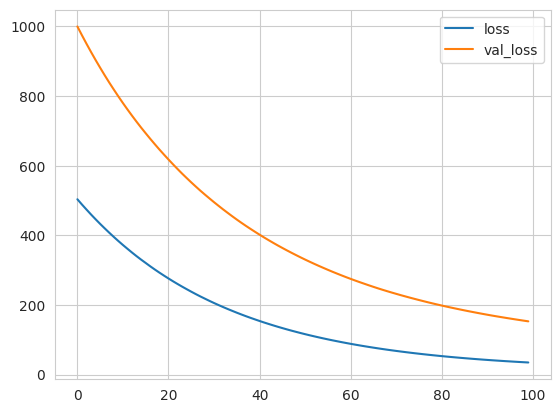

In [66]:
plot_loss(history)

In [70]:
X_test_numeric = X_test.copy()
for col in X_test_numeric.select_dtypes(include=['category']).columns:
    X_test_numeric[col] = X_test_numeric[col].cat.codes
X_test_numeric['horsepower'] = X_test_numeric['horsepower'].fillna(X_train_numeric['horsepower'].median())


X_test_np = np.array(X_test_numeric, dtype=np.float32)
y_test_np = np.array(y_test, dtype=np.float32)

y_pred = linear_model.predict(X_test_np)
print(np.sqrt(mean_squared_error(y_test_np, y_pred)))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
6.385018050512551
